# Load the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance"
print(os.listdir(DATA_DIR))

['PdM_errors.csv', 'PdM_telemetry.csv', 'PdM_failures.csv', 'PdM_machines.csv', 'PdM_maint.csv']


In [2]:
telemetry = pd.read_csv(f"{DATA_DIR}/PdM_telemetry.csv", parse_dates=["datetime"])
errors    = pd.read_csv(f"{DATA_DIR}/PdM_errors.csv",    parse_dates=["datetime"])
maint     = pd.read_csv(f"{DATA_DIR}/PdM_maint.csv",     parse_dates=["datetime"])
failures  = pd.read_csv(f"{DATA_DIR}/PdM_failures.csv",  parse_dates=["datetime"])
machines  = pd.read_csv(f"{DATA_DIR}/PdM_machines.csv")

for name, df in [("telemetry", telemetry), ("errors", errors),
                  ("maint", maint), ("failures", failures), ("machines", machines)]:
    print(f"\n--- {name} ---")
    print("shape:", df.shape)
    print(df.dtypes)
    print(df.head(3))


--- telemetry ---
shape: (876100, 6)
datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object
             datetime  machineID        volt      rotate    pressure  \
0 2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1 2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2 2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  

--- errors ---
shape: (3919, 3)
datetime     datetime64[ns]
machineID             int64
errorID              object
dtype: object
             datetime  machineID errorID
0 2015-01-03 07:00:00          1  error1
1 2015-01-03 20:00:00          1  error3
2 2015-01-04 06:00:00          1  error5

--- maint ---
shape: (3286, 3)
datetime     datetime64[ns]
machineID             int64
comp                 object
dtype: object
      

# basic shape sanity checks

In [3]:
print("unique machines (telemetry):", telemetry["machineID"].nunique())
print("date range:", telemetry["datetime"].min(), "to", telemetry["datetime"].max())
print("\nfailure types:\n", failures["failure"].value_counts())
print("\nerror codes:\n", errors["errorID"].value_counts())
print("\nfailures per machine — summary:\n", failures.groupby("machineID").size().describe())
print("\nmissing values per table:")
for name, df in [("telemetry", telemetry), ("errors", errors), ("maint", maint), ("failures", failures)]:
    print(name, df.isna().sum().to_dict())

dup = telemetry.duplicated(subset=["machineID", "datetime"]).sum()
print("\nduplicate (machineID, datetime) rows in telemetry:", dup)

unique machines (telemetry): 100
date range: 2015-01-01 06:00:00 to 2016-01-01 06:00:00

failure types:
 failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

error codes:
 errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

failures per machine — summary:
 count    98.000000
mean      7.765306
std       3.463509
min       2.000000
25%       5.000000
50%       7.000000
75%      10.000000
max      19.000000
dtype: float64

missing values per table:
telemetry {'datetime': 0, 'machineID': 0, 'volt': 0, 'rotate': 0, 'pressure': 0, 'vibration': 0}
errors {'datetime': 0, 'machineID': 0, 'errorID': 0}
maint {'datetime': 0, 'machineID': 0, 'comp': 0}
failures {'datetime': 0, 'machineID': 0, 'failure': 0}

duplicate (machineID, datetime) rows in telemetry: 0


# check for dropped/missing timestamps (sensor dropout)

In [4]:
full_range = pd.date_range(telemetry["datetime"].min(), telemetry["datetime"].max(), freq="h")

gap_counts = {}
for mid, g in telemetry.groupby("machineID"):
    missing = full_range.difference(pd.DatetimeIndex(g["datetime"]))
    gap_counts[mid] = len(missing)

gap_series = pd.Series(gap_counts).sort_values(ascending=False)
print("expected hours per machine:", len(full_range))
print("worst 10 machines by missing hours:\n", gap_series.head(10))
print("total missing machine-hours across the dataset:", gap_series.sum())

expected hours per machine: 8761
worst 10 machines by missing hours:
 1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
dtype: int64
total missing machine-hours across the dataset: 0


#  Check for out of bounds spikes (hardware noise)

In [5]:
sensor_cols = ["volt", "rotate", "pressure", "vibration"]
print(telemetry[sensor_cols].describe())

for col in sensor_cols:
    q1, q3 = telemetry[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((telemetry[col] < low) | (telemetry[col] > high)).sum()
    print(f"{col}: IQR-based bounds [{low:.2f}, {high:.2f}] -> {n_out} extreme outliers "
          f"({n_out/len(telemetry):.3%} of rows)")

                volt         rotate       pressure      vibration
count  876100.000000  876100.000000  876100.000000  876100.000000
mean      170.777736     446.605119     100.858668      40.385007
std        15.509114      52.673886      11.048679       5.370361
min        97.333604     138.432075      51.237106      14.877054
25%       160.304927     412.305714      93.498181      36.777299
50%       170.607338     447.558150     100.425559      40.237247
75%       181.004493     482.176600     107.555231      43.784938
max       255.124717     695.020984     185.951998      76.791072
volt: IQR-based bounds [98.21, 243.10] -> 18 extreme outliers (0.002% of rows)
rotate: IQR-based bounds [202.69, 691.79] -> 48 extreme outliers (0.005% of rows)
pressure: IQR-based bounds [51.33, 149.73] -> 381 extreme outliers (0.043% of rows)
vibration: IQR-based bounds [15.75, 64.81] -> 181 extreme outliers (0.021% of rows)


# visualize one machine to eyeball noise and failure alignment

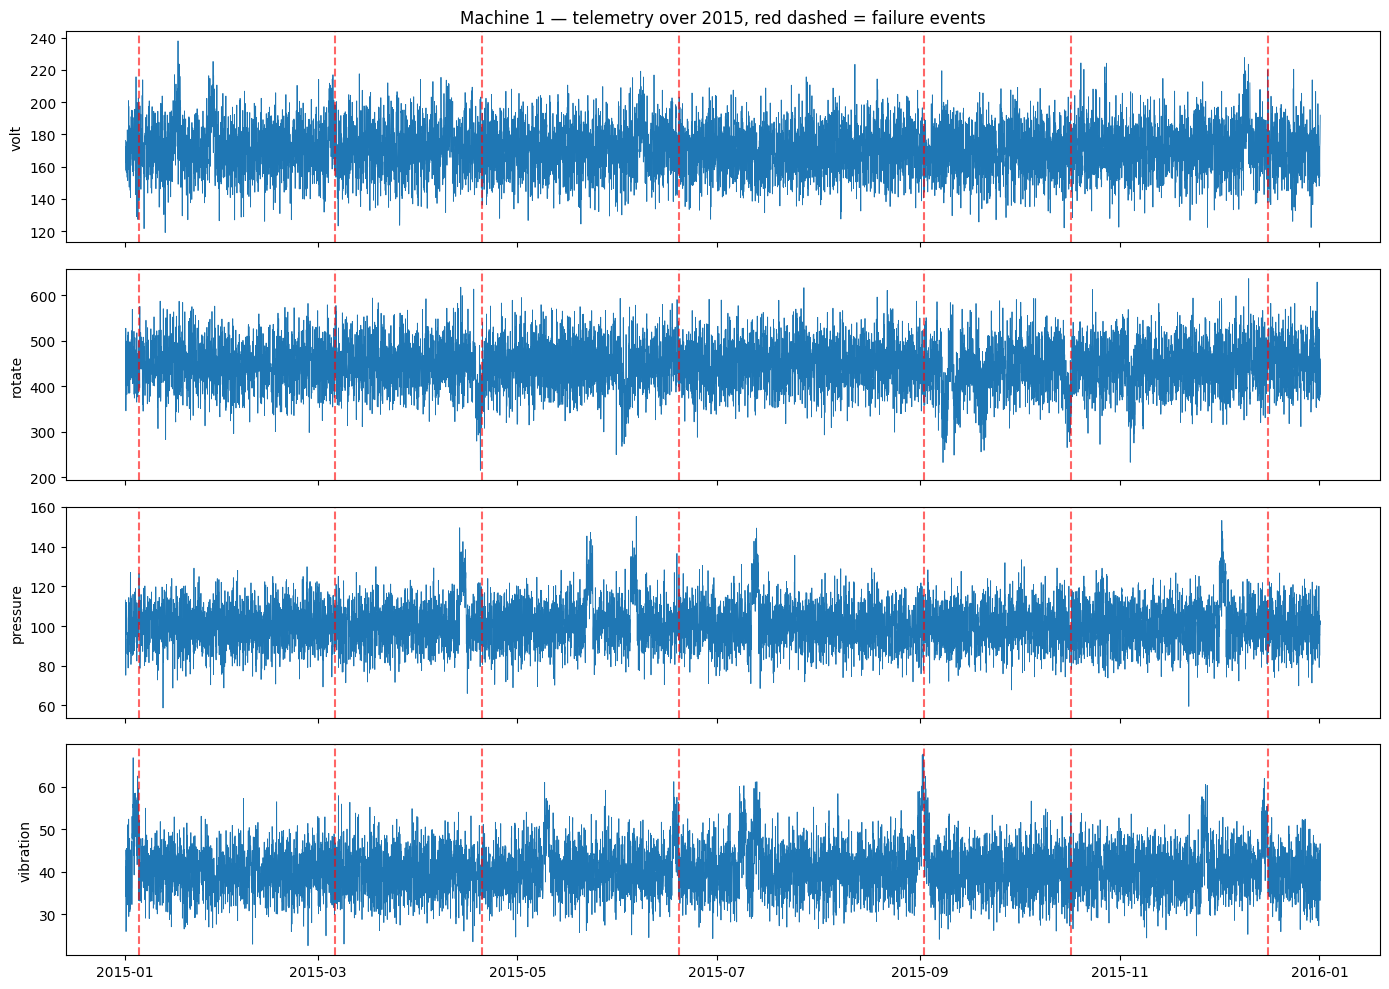

In [6]:
sample_id = 1
sample = telemetry[telemetry["machineID"] == sample_id].set_index("datetime").sort_index()
machine_failures = failures[failures["machineID"] == sample_id]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, sensor_cols):
    ax.plot(sample.index, sample[col], linewidth=0.6)
    ax.set_ylabel(col)
    for ts in machine_failures["datetime"]:
        ax.axvline(ts, color="red", linestyle="--", alpha=0.6)
axes[0].set_title(f"Machine {sample_id} — telemetry over 2015, red dashed = failure events")
plt.tight_layout()
plt.show()

# confirm no physically impossible readings

In [7]:
# physically impossible would be zero/negative sensor value
for col in sensor_cols:
    n_bad = (telemetry[col] <= 0).sum()
    print(f"{col}: {n_bad} non-positive readings")

volt: 0 non-positive readings
rotate: 0 non-positive readings
pressure: 0 non-positive readings
vibration: 0 non-positive readings


In [8]:
# defensive reindex: guarantees a continuous hourly grid per machine
def reindex_machine(g, full_idx):
    g = g.set_index("datetime").reindex(full_idx)
    g["machineID"] = g["machineID"].ffill().bfill()
    return g

reindexed = [reindex_machine(g, full_range) for _, g in telemetry.groupby("machineID")]
telemetry_clean = pd.concat(reindexed).rename_axis("datetime").reset_index()

print("rows needing interpolation:", telemetry_clean[sensor_cols].isna().sum().to_dict())

telemetry_clean[sensor_cols] = (
    telemetry_clean.groupby("machineID")[sensor_cols]
    .apply(lambda g: g.interpolate(limit=3))
    .reset_index(drop=True)
)

rows needing interpolation: {'volt': 0, 'rotate': 0, 'pressure': 0, 'vibration': 0}


# turn the outliers into a feature

In [9]:
for col in sensor_cols:
    q1, q3 = telemetry_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 3 * iqr, q3 + 3 * iqr
    telemetry_clean[f"{col}_extreme"] = ((telemetry_clean[col] < low) | (telemetry_clean[col] > high)).astype(int)

print(telemetry_clean[[f"{c}_extreme" for c in sensor_cols]].sum())

volt_extreme          18
rotate_extreme        48
pressure_extreme     381
vibration_extreme    181
dtype: int64


# the actual prediction target

In [10]:
tel_sorted = telemetry_clean.sort_values(["datetime", "machineID"]).reset_index(drop=True)
fail_sorted = failures.sort_values(["datetime", "machineID"])[["machineID", "datetime", "failure"]]
fail_sorted = fail_sorted.rename(columns={"datetime": "next_failure_time", "failure": "next_failure_type"})

labeled = pd.merge_asof(
    tel_sorted, fail_sorted,
    left_on="datetime", right_on="next_failure_time",
    by="machineID", direction="forward"
)

labeled["hours_to_failure"] = (labeled["next_failure_time"] - labeled["datetime"]).dt.total_seconds() / 3600
labeled["fails_in_24h"] = ((labeled["hours_to_failure"] >= 0) & (labeled["hours_to_failure"] <= 24)).fillna(False).astype(int)

print(labeled["fails_in_24h"].value_counts())
print("positive rate:", labeled["fails_in_24h"].mean())
print("\nby next failure type (for context, not used as a feature):")
print(labeled.loc[labeled["fails_in_24h"] == 1, "next_failure_type"].value_counts())

fails_in_24h
0    858198
1     17902
Name: count, dtype: int64
positive rate: 0.020433740440588974

by next failure type (for context, not used as a feature):
next_failure_type
comp2    6241
comp1    4773
comp4    3866
comp3    3022
Name: count, dtype: int64


# telemetry lags and rolling stats

In [11]:
g = labeled.groupby("machineID")

for col in sensor_cols:
    for lag in [1, 2, 3]:
        labeled[f"{col}_lag{lag}"] = g[col].shift(lag)

    labeled[f"{col}_mean_3h"]  = g[col].transform(lambda s: s.rolling(3,  min_periods=3).mean())
    labeled[f"{col}_std_3h"]   = g[col].transform(lambda s: s.rolling(3,  min_periods=3).std())
    labeled[f"{col}_mean_24h"] = g[col].transform(lambda s: s.rolling(24, min_periods=24).mean())
    labeled[f"{col}_std_24h"]  = g[col].transform(lambda s: s.rolling(24, min_periods=24).std())
    labeled[f"{col}_min_24h"]  = g[col].transform(lambda s: s.rolling(24, min_periods=24).min())
    labeled[f"{col}_max_24h"]  = g[col].transform(lambda s: s.rolling(24, min_periods=24).max())

print(labeled.filter(like="_24h").isna().sum().head())

fails_in_24h        0
volt_mean_24h    2300
volt_std_24h     2300
volt_min_24h     2300
volt_max_24h     2300
dtype: int64


# error frequency, last 24 hours

In [12]:
errors_wide = (
    errors.pivot_table(index=["datetime", "machineID"], columns="errorID", aggfunc="size", fill_value=0)
    .reset_index()
)
errors_wide.columns = ["datetime", "machineID"] + [f"err_{c}" for c in errors_wide.columns[2:]]

labeled = labeled.merge(errors_wide, on=["datetime", "machineID"], how="left")
err_cols = [c for c in errors_wide.columns if c.startswith("err_")]
labeled[err_cols] = labeled[err_cols].fillna(0)

g = labeled.groupby("machineID")
for col in err_cols:
    labeled[f"{col}_24h_sum"] = g[col].transform(lambda s: s.rolling(24, min_periods=1).sum())

# hours since last maintenance, per component

In [13]:
base = labeled.sort_values(["datetime", "machineID"]).reset_index(drop=True)

for comp in sorted(maint["comp"].unique()):
    comp_maint = (
        maint[maint["comp"] == comp]
        .sort_values(["datetime", "machineID"])[["machineID", "datetime"]]
        .rename(columns={"datetime": f"last_{comp}_dt"})
    )
    base = pd.merge_asof(
        base, comp_maint,
        left_on="datetime", right_on=f"last_{comp}_dt",
        by="machineID", direction="backward"
    )
    base[f"hours_since_{comp}"] = (base["datetime"] - base[f"last_{comp}_dt"]).dt.total_seconds() / 3600
    base.drop(columns=[f"last_{comp}_dt"], inplace=True)

maint_cols = [c for c in base.columns if c.startswith("hours_since_")]
print("rows before any recorded replacement (NaN):\n", base[maint_cols].isna().sum())
base[maint_cols] = base[maint_cols].fillna(base[maint_cols].max())
labeled = base

rows before any recorded replacement (NaN):
 hours_since_comp1    0
hours_since_comp2    0
hours_since_comp3    0
hours_since_comp4    0
dtype: int64


 # machine metadata, assemble final table, drop warm-up rows

In [14]:
labeled = labeled.merge(machines, on="machineID", how="left")
labeled = pd.get_dummies(labeled, columns=["model"], prefix="model")

feature_table = labeled.drop(columns=["next_failure_time", "next_failure_type", "hours_to_failure"])

before = len(feature_table)
feature_table = feature_table.dropna()
after = len(feature_table)
print(f"dropped {before - after} rows ({(before - after)/before:.3%}) — these are the first ~24h per machine before rolling windows fill up")
print(feature_table.shape)
print("positive rate after dropping warm-up rows:", feature_table["fails_in_24h"].mean())

dropped 2300 rows (0.263%) — these are the first ~24h per machine before rolling windows fill up
(873800, 66)
positive rate after dropping warm-up rows: 0.02000572213321126


# Train, Test Split and Modeling

## Time-based split

In [15]:
cutoff = pd.Timestamp("2015-10-01")

train = feature_table[feature_table["datetime"] < cutoff].drop(columns=["datetime", "machineID"])
test  = feature_table[feature_table["datetime"] >= cutoff].drop(columns=["datetime", "machineID"])

X_train = train.drop(columns=["fails_in_24h"])
y_train = train["fails_in_24h"]
X_test  = test.drop(columns=["fails_in_24h"])
y_test  = test["fails_in_24h"]

print("train:", X_train.shape, "| positive rate:", y_train.mean().round(4))
print("test: ", X_test.shape,  "| positive rate:", y_test.mean().round(4))

train: (652300, 63) | positive rate: 0.0203
test:  (221500, 63) | positive rate: 0.0191


## Train LightGBM classifier with class weighting

In [16]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos  # tells the model positives are ~49x rarer
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

scale_pos_weight: 48.2
[LightGBM] [Info] Number of positive: 13260, number of negative: 639040
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.208995 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11279
[LightGBM] [Info] Number of data points in the train set: 652300, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.020328 -> initscore=-3.875215
[LightGBM] [Info] Start training from score -3.875215
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.00153934
Early stopping, best iteration is:
[130]	valid_0's binary_logloss: 0.00140489


LGBMClassifier(learning_rate=0.05, n_estimators=500, n_jobs=-1, num_leaves=63,
               random_state=42, scale_pos_weight=np.float64(48.19306184012066))

## Evaluate

In [17]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:           ", roc_auc_score(y_test, y_proba).round(4))
print("Avg Precision (PR):", average_precision_score(y_test, y_proba).round(4))

              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9998    217279
           1     0.9843    0.9983    0.9913      4221

    accuracy                         0.9997    221500
   macro avg     0.9922    0.9990    0.9956    221500
weighted avg     0.9997    0.9997    0.9997    221500

ROC-AUC:            1.0
Avg Precision (PR): 0.9989


In [18]:
# top 10 most important features
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

hours_since_comp1     611
hours_since_comp4     549
volt_mean_24h         489
rotate_mean_24h       474
hours_since_comp2     454
hours_since_comp3     421
vibration_min_24h     339
vibration_mean_24h    308
pressure_mean_24h     247
volt_min_24h          236
dtype: int32


# Visualization

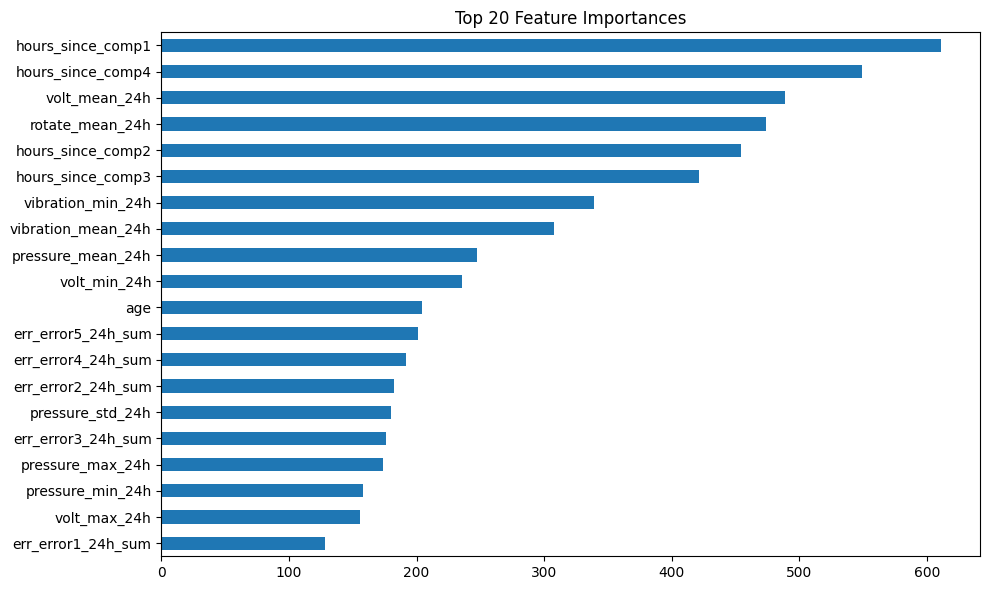

In [19]:
import matplotlib.pyplot as plt

# Feature importance plot
plt.figure(figsize=(10, 6))
importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

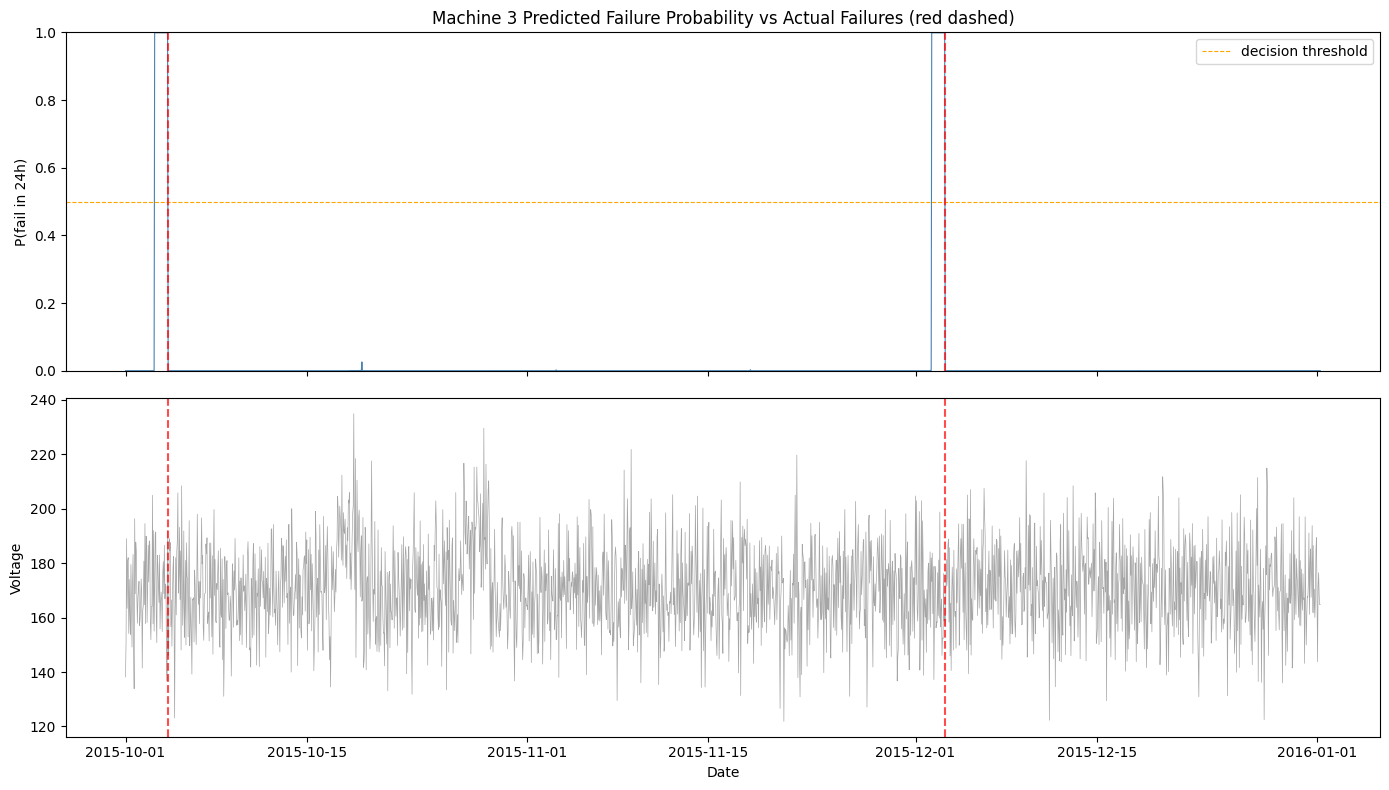

In [20]:
machine_id = 3
test_machine = feature_table[
    (feature_table["machineID"] == machine_id) &
    (feature_table["datetime"] >= pd.Timestamp("2015-10-01"))
].copy()

X_vis = test_machine.drop(columns=["datetime", "machineID", "fails_in_24h"])
test_machine["pred_proba"] = model.predict_proba(X_vis)[:, 1]

machine_failures = failures[
    (failures["machineID"] == machine_id) &
    (failures["datetime"] >= pd.Timestamp("2015-10-01"))
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# top panel: predicted failure probability
ax1.plot(test_machine["datetime"], test_machine["pred_proba"], color="steelblue", linewidth=0.8)
ax1.axhline(0.5, color="orange", linestyle="--", linewidth=0.8, label="decision threshold")
for _, row in machine_failures.iterrows():
    ax1.axvline(row["datetime"], color="red", linestyle="--", alpha=0.7)
ax1.set_ylabel("P(fail in 24h)")
ax1.set_ylim(0, 1)
ax1.set_title(f"Machine {machine_id} Predicted Failure Probability vs Actual Failures (red dashed)")
ax1.legend()

# bottom panel: raw voltage as context
ax2.plot(test_machine["datetime"], test_machine["volt"], color="grey", linewidth=0.5, alpha=0.7)
for _, row in machine_failures.iterrows():
    ax2.axvline(row["datetime"], color="red", linestyle="--", alpha=0.7)
ax2.set_ylabel("Voltage")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

## final visualization

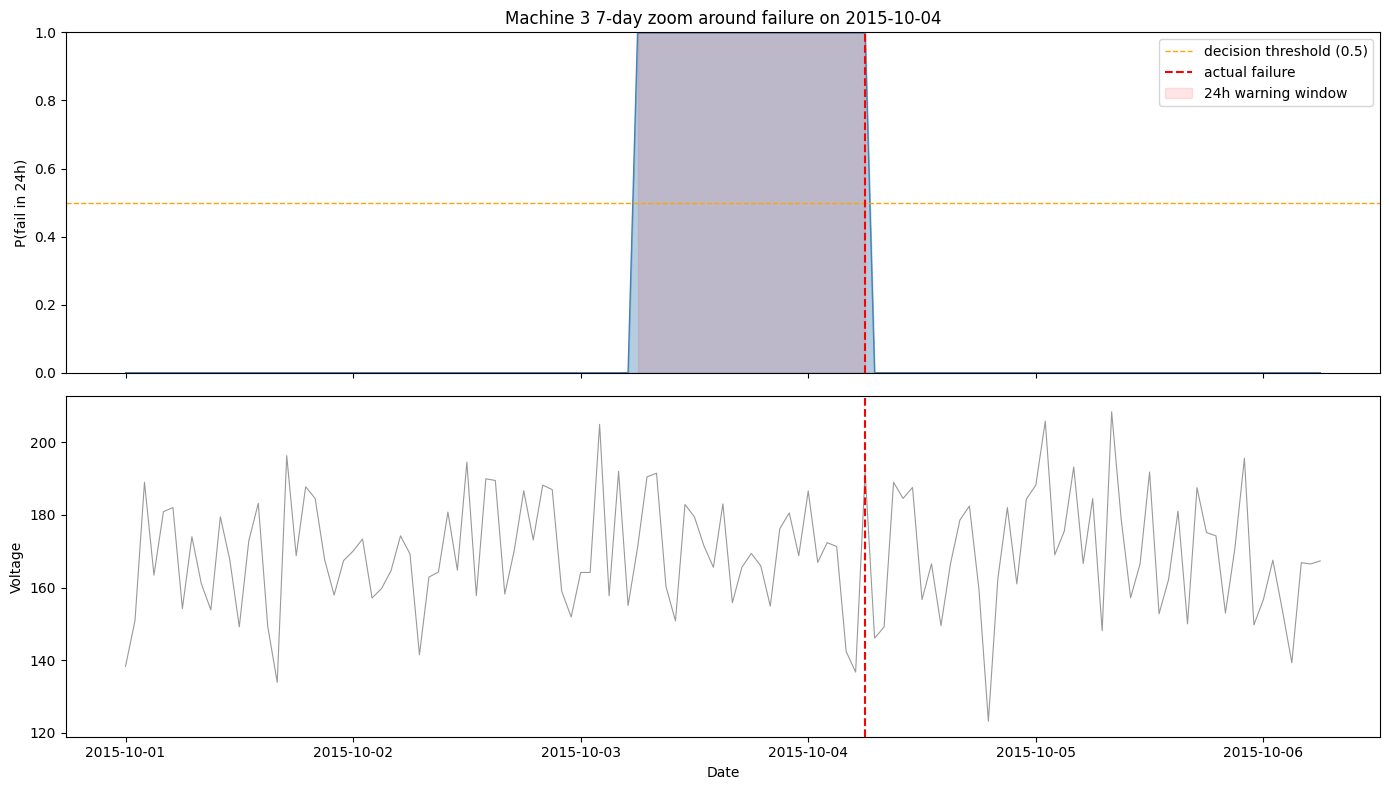

In [21]:
# zoom into a 7-day window around the first failure
first_failure = machine_failures["datetime"].iloc[0]
window_start = first_failure - pd.Timedelta(days=5)
window_end   = first_failure + pd.Timedelta(days=2)

zoomed = test_machine[
    (test_machine["datetime"] >= window_start) &
    (test_machine["datetime"] <= window_end)
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.fill_between(zoomed["datetime"], zoomed["pred_proba"], alpha=0.4, color="steelblue")
ax1.plot(zoomed["datetime"], zoomed["pred_proba"], color="steelblue", linewidth=1)
ax1.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="decision threshold (0.5)")
ax1.axvline(first_failure, color="red", linestyle="--", linewidth=1.5, label="actual failure")
ax1.axvspan(first_failure - pd.Timedelta(hours=24), first_failure,
            alpha=0.1, color="red", label="24h warning window")
ax1.set_ylabel("P(fail in 24h)")
ax1.set_ylim(0, 1)
ax1.set_title(f"Machine {machine_id} 7-day zoom around failure on {first_failure.date()}")
ax1.legend()

ax2.plot(zoomed["datetime"], zoomed["volt"], color="grey", linewidth=0.8, alpha=0.8)
ax2.axvline(first_failure, color="red", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Voltage")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()